
── Energy Resolution Analysis ──────────────────────
Scenario                  Peak (e)     FWHM (e)     FWHM (keV)   %       
────────────────────────────────────────────────────────────────────────
Baseline CdTe             13.5         0.3          0.00         2.2     
Perovskite CsPbBr3        11.3         0.3          0.00         3.0     
S1 — 20 keV               4.5          0.2          0.00         5.4     
S1 — 60 keV               13.5         0.3          0.00         2.2     
S1 — 100 keV              22.6         0.3          0.00         1.4     
S1 — 150 keV              33.8         0.4          0.00         1.2     
S2 — Fresh                13.5         0.3          0.00         2.2     
S2 — Heavy                2.7          4.6          0.02         169.3   
S2 — Severe               1.2          1.2          0.01         96.1    
S6 — Fine pitch           13.5         0.3          0.00         2.2     
S6 — Spectroscopic        13.5         0.3          0.00   

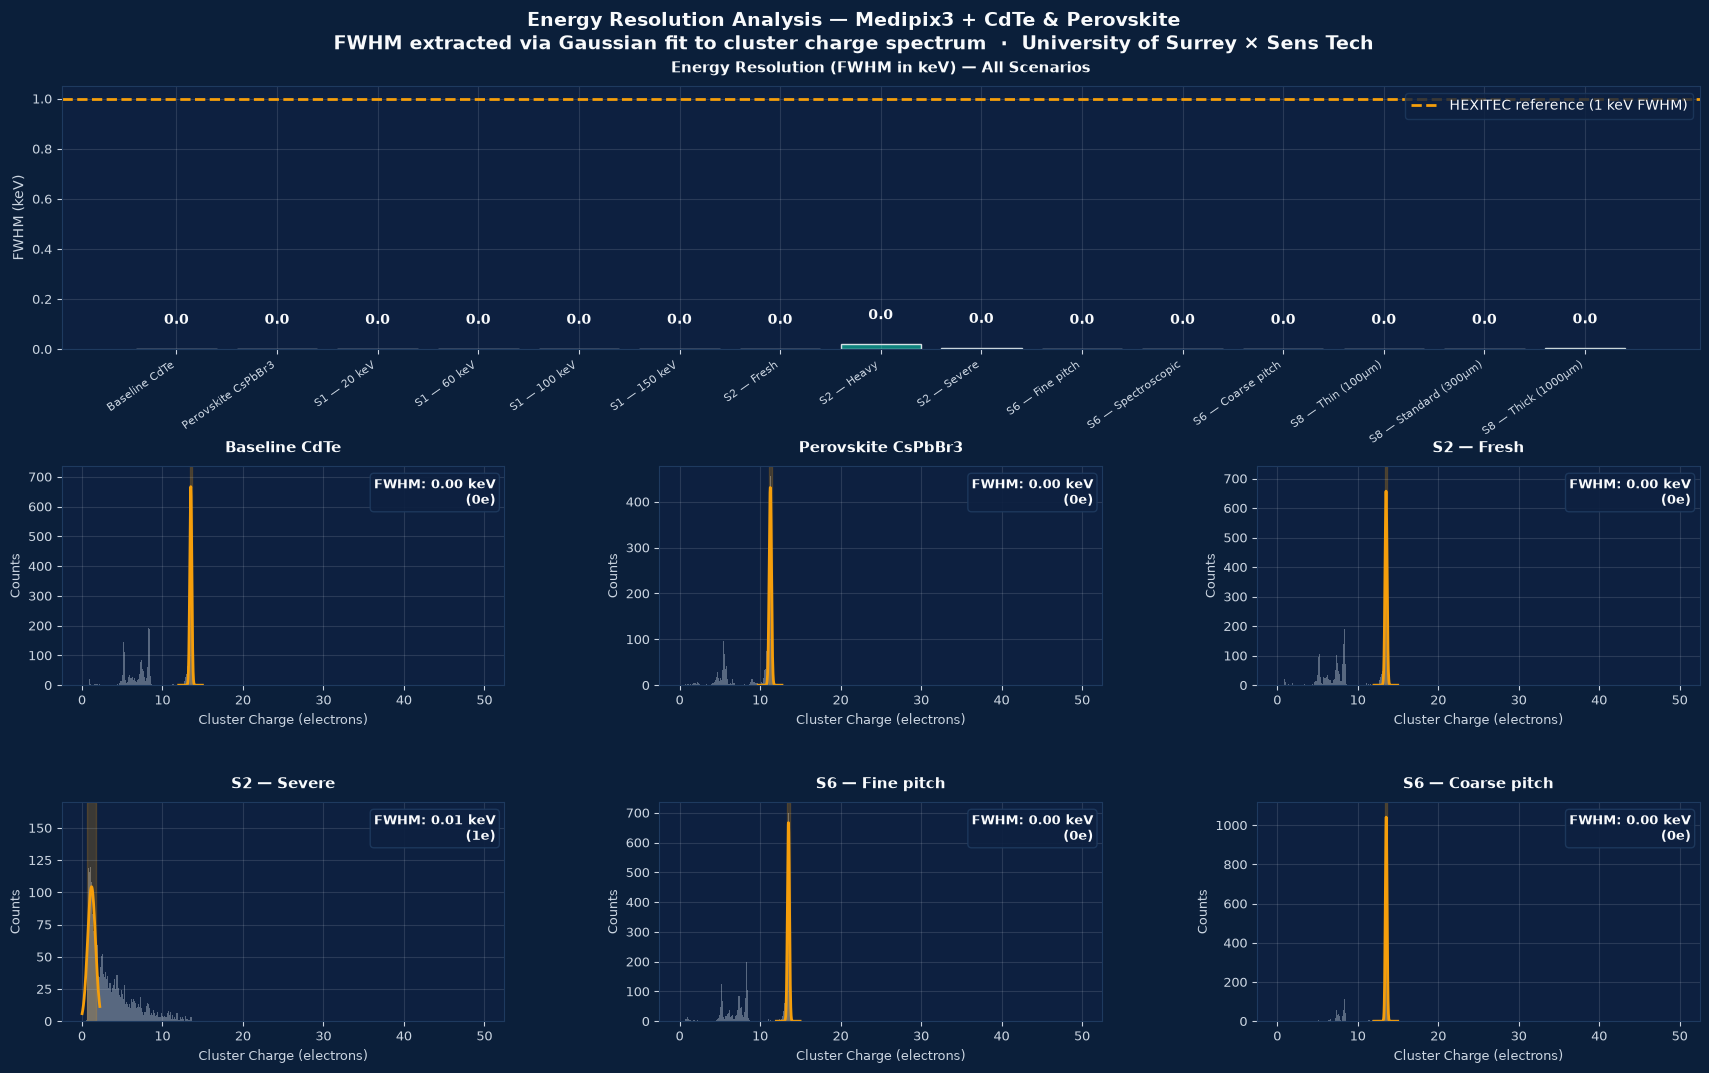


Saved: /home/victor-pc/itek/senstech-simulation/analysis/notebooks/energy_resolution_analysis.png

*** Note: FWHM in keV calculated using CdTe ionisation energy of 4.4 eV/pair ***


In [1]:
"""
Energy Resolution Analysis — extracted from all scenario ROOT files
Measures FWHM of the cluster charge spectrum at each operating point.
"""

import os
os.environ["QT_QPA_PLATFORM"] = "xcb"

import uproot
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import matplotlib.gridspec as gridspec

BASE = os.path.expanduser("~/itek/senstech-simulation/data")
DET = "medipix3_detector"
CDTE_IONISATION_EV = 4.4   # eV per electron-hole pair

# ── Gaussian fitting helper ───────────────────────────────────────────────
def gaussian(x, amp, mu, sigma):
    return amp * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def extract_energy_resolution(root_path, det=DET):
    """Extract FWHM of cluster charge peak from a ROOT file."""
    try:
        f = uproot.open(root_path)
        cc = f[f"DetectorHistogrammer/{det}/charge/cluster_charge;1"].to_numpy()
        counts = cc[0]
        edges = cc[1]
        centres = (edges[:-1] + edges[1:]) / 2

        mask = counts > 0
        if mask.sum() < 5:
            return None

        # Focus on right half of distribution (the photopeak)
        peak_idx = np.argmax(counts)
        # Fit window around peak
        window = 30
        lo = max(0, peak_idx - window)
        hi = min(len(counts), peak_idx + window)

        x_fit = centres[lo:hi]
        y_fit = counts[lo:hi]

        # Initial guesses
        amp_guess = y_fit.max()
        mu_guess = centres[peak_idx]
        sigma_guess = (edges[hi-1] - edges[lo]) / 6

        popt, _ = curve_fit(gaussian, x_fit, y_fit,
                             p0=[amp_guess, mu_guess, sigma_guess],
                             maxfev=5000)
        amp, mu, sigma = popt
        fwhm_electrons = abs(sigma) * 2.355
        fwhm_keV = fwhm_electrons * CDTE_IONISATION_EV / 1000

        return {
            "peak_centre_e": mu,
            "fwhm_electrons": fwhm_electrons,
            "fwhm_keV": fwhm_keV,
            "resolution_pct": (fwhm_keV / (mu * CDTE_IONISATION_EV / 1000)) * 100
                              if mu > 0 else None,
            "fit_x": x_fit, "fit_y": y_fit, "popt": popt,
            "all_centres": centres, "all_counts": counts,
        }
    except Exception as e:
        print(f"  Error: {e}")
        return None

# ── Files to analyse ──────────────────────────────────────────────────────
scenarios = {
    "Baseline CdTe":     "medipix3_cdte_REAL.root",
    "Perovskite CsPbBr3": "medipix3_perovskite_v1.root",
    "S1 — 20 keV":  "s1_cdte_20keV.root",
    "S1 — 60 keV":  "s1_cdte_60keV.root",
    "S1 — 100 keV": "s1_cdte_100keV.root",
    "S1 — 150 keV": "s1_cdte_150keV.root",
    "S2 — Fresh":     "s2_v4_fresh.root",
    "S2 — Heavy":     "s2_v4_heavy.root",
    "S2 — Severe":    "s2_v4_severe.root",
    "S6 — Fine pitch":     "s6_cdte_pitchfine.root",
    "S6 — Spectroscopic":  "s6_cdte_pitchspectro.root",
    "S6 — Coarse pitch":   "s6_cdte_pitchcoarse.root",
    "S8 — Thin (100μm)":   "s8_cdte_thick100um.root",
    "S8 — Standard (300μm)": "s8_cdte_thick300um.root",
    "S8 — Thick (1000μm)":   "s8_cdte_thick1000um.root",
}

print("\n── Energy Resolution Analysis ──────────────────────")
print(f"{'Scenario':<25} {'Peak (e)':<12} {'FWHM (e)':<12} {'FWHM (keV)':<12} {'%':<8}")
print("─" * 72)

results = []
for label, fname in scenarios.items():
    path = os.path.join(BASE, fname)
    if not os.path.exists(path):
        print(f"{label:<25} MISSING")
        continue
    r = extract_energy_resolution(path)
    if r is None:
        print(f"{label:<25} fit failed")
        continue
    pct = r["resolution_pct"] if r["resolution_pct"] else 0
    print(f"{label:<25} {r['peak_centre_e']:<12.1f} "
          f"{r['fwhm_electrons']:<12.1f} {r['fwhm_keV']:<12.2f} {pct:<8.1f}")
    results.append({"label": label, **r})

# ── Plot: focused energy resolution dashboard ─────────────────────────────
NAVY, WHITE, LGRAY, TEAL = "#0B1F3A", "#F8FAFC", "#CBD5E1", "#0D9488"
PURP, AMBER, BLUE = "#7C3AED", "#D97706", "#0369A1"

def style_ax(ax, title):
    ax.set_facecolor("#0D2040")
    ax.tick_params(colors=LGRAY, labelsize=9)
    ax.xaxis.label.set_color(LGRAY); ax.yaxis.label.set_color(LGRAY)
    ax.title.set_color(WHITE)
    ax.set_title(title, fontweight="bold", fontsize=11, pad=10)
    for s in ax.spines.values(): s.set_edgecolor("#1E3A5F")
    ax.grid(True, alpha=0.15, color=LGRAY)

# Pick a representative subset of 6 to visualise the fits
display_subset = ["Baseline CdTe", "Perovskite CsPbBr3",
                  "S2 — Fresh", "S2 — Severe",
                  "S6 — Fine pitch", "S6 — Coarse pitch"]
display_results = [r for r in results if r["label"] in display_subset]

fig = plt.figure(figsize=(18, 11))
fig.patch.set_facecolor(NAVY)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.35,
                       left=0.06, right=0.97, top=0.91, bottom=0.06,
                       height_ratios=[1.2, 1, 1])

# Top panel — FWHM bar comparison
ax_top = fig.add_subplot(gs[0, :])
style_ax(ax_top, "Energy Resolution (FWHM in keV) — All Scenarios")
labels = [r["label"] for r in results]
fwhms = [r["fwhm_keV"] for r in results]
colors = []
for label in labels:
    if "Baseline" in label or "S2" in label:
        colors.append(TEAL)
    elif "Perovskite" in label:
        colors.append(PURP)
    elif "S1" in label:
        colors.append(BLUE)
    elif "S6" in label:
        colors.append(AMBER)
    elif "S8" in label:
        colors.append("#16A34A")
    else:
        colors.append(LGRAY)
bars = ax_top.bar(range(len(labels)), fwhms, color=colors, alpha=0.85,
                  edgecolor=WHITE, linewidth=1)
for bar, fwhm in zip(bars, fwhms):
    ax_top.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f"{fwhm:.1f}", ha="center", color=WHITE,
                fontsize=10, fontweight="bold")
ax_top.set_xticks(range(len(labels)))
ax_top.set_xticklabels(labels, rotation=35, ha="right", fontsize=8)
ax_top.set_ylabel("FWHM (keV)")
# Reference line for HEXITEC's published 1 keV FWHM
ax_top.axhline(y=1, color="#F59E0B", linestyle="--", linewidth=2,
               label="HEXITEC reference (1 keV FWHM)")
ax_top.legend(loc="upper right", fontsize=10, labelcolor=WHITE,
              facecolor="#0D2040", edgecolor="#1E3A5F")

# Fit panels — 6 representative scenarios
for i, r in enumerate(display_results):
    row, col = divmod(i, 3)
    ax = fig.add_subplot(gs[row + 1, col])
    style_ax(ax, r["label"])
    # Show histogram
    ax.bar(r["all_centres"], r["all_counts"],
           width=(r["all_centres"][1] - r["all_centres"][0]),
           color=LGRAY, alpha=0.4, label="Data")
    # Show fit
    x_fine = np.linspace(r["fit_x"][0], r["fit_x"][-1], 200)
    ax.plot(x_fine, gaussian(x_fine, *r["popt"]),
            color="#F59E0B", linewidth=2, label="Gaussian fit")
    # Mark FWHM
    mu = r["popt"][1]
    sigma = abs(r["popt"][2])
    ax.axvspan(mu - sigma * 1.1775, mu + sigma * 1.1775,
               alpha=0.2, color="#F59E0B")
    ax.set_xlabel("Cluster Charge (electrons)", fontsize=9)
    ax.set_ylabel("Counts", fontsize=9)
    ax.text(0.98, 0.95,
            f"FWHM: {r['fwhm_keV']:.2f} keV\n({r['fwhm_electrons']:.0f}e)",
            transform=ax.transAxes, ha="right", va="top", fontsize=9,
            color=WHITE, fontweight="bold",
            bbox=dict(boxstyle="round", facecolor="#0D2040",
                      edgecolor="#1E3A5F", alpha=0.9))

fig.suptitle("Energy Resolution Analysis — Medipix3 + CdTe & Perovskite\n"
             "FWHM extracted via Gaussian fit to cluster charge spectrum  ·  University of Surrey × Sens Tech",
             fontsize=14, fontweight="bold", color=WHITE, y=0.98)

out_dir = os.path.expanduser("~/itek/senstech-simulation/analysis/notebooks")
os.makedirs(out_dir, exist_ok=True)
out = os.path.join(out_dir, "energy_resolution_analysis.png")
plt.savefig(out, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"\nSaved: {out}")
print("\n*** Note: FWHM in keV calculated using CdTe ionisation energy of 4.4 eV/pair ***")